In [6]:
from astropy import units as u, time
import numpy as np
import matplotlib.pyplot as plt
from poliastro.bodies import Earth, Mars, Sun
from poliastro.ephem import Ephem
from poliastro.twobody import Orbit
from poliastro.maneuver import Maneuver
from poliastro.plotting import StaticOrbitPlotter
from poliastro.util import time_range
from astropy.coordinates import solar_system_ephemeris
solar_system_ephemeris.set("jpl")

<ScienceState solar_system_ephemeris: 'jpl'>

In [7]:
# Brute-force Lambert: scan departure dates with a fixed transit time
transit = 200 * u.day
start   = time.Time("2026-01-01", scale="tdb")
end     = time.Time("2035-12-31", scale="tdb")
step    = 5 * u.day

ephem_e = Ephem.from_body(Earth, time_range(start, end=end + transit))
ephem_m = Ephem.from_body(Mars,  time_range(start, end=end + transit))

dvs, dates = [], []
best_dv, best_date, best_orb = 1e9, None, None

for i in range(int(((end - start) / step).value)):
    t0, t1 = start + i * step, start + i * step + transit
    ss0 = Orbit.from_ephem(Sun, ephem_e, t0)
    ss1 = Orbit.from_ephem(Sun, ephem_m, t1)
    try:
        man = Maneuver.lambert(ss0, ss1)
        dv  = np.linalg.norm(man[0][1].value)
        dvs.append(dv); dates.append(t0.datetime)
        if dv < best_dv:
            best_dv, best_date = dv, t0
            best_orb, _ = ss0.apply_maneuver(man, intermediate=True)
    except: pass

print(f"Best departure: {best_date.iso[:10]}  |  ΔV sun frame: {best_dv:.2f}")

Best departure: 2035-06-23  |  ΔV sun frame: 3028.40


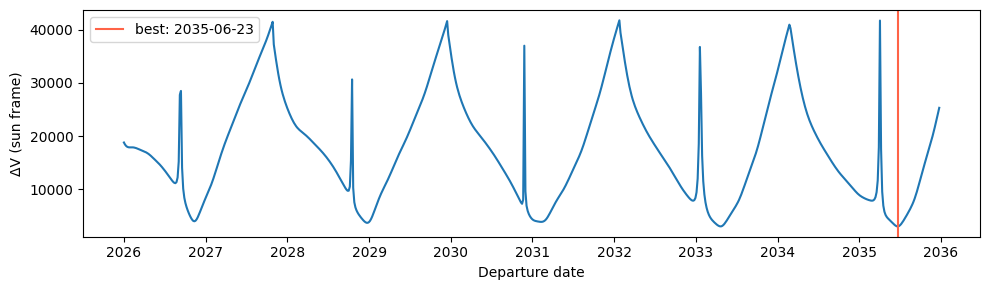

In [8]:
# ΔV profile — dips are launch windows
plt.figure(figsize=(10, 3))
plt.plot(dates, dvs)
plt.axvline(best_date.datetime, color="tomato", label=f"best: {best_date.iso[:10]}")
plt.ylabel("ΔV (sun frame)"); plt.xlabel("Departure date"); plt.legend()
plt.tight_layout()

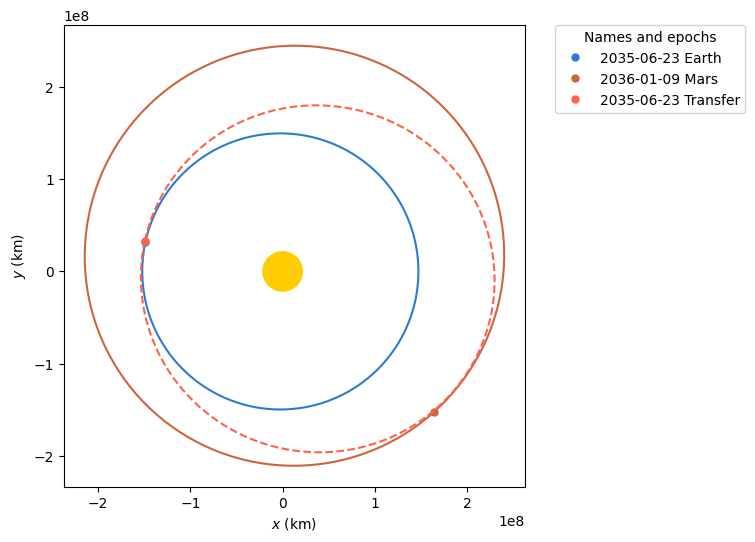

In [10]:
# Plot the best trajectory
plotter = StaticOrbitPlotter()
plotter.plot_body_orbit(Earth, best_date, label="Earth")
plotter.plot_body_orbit(Mars,  best_date + transit, label="Mars")
plotter.plot(best_orb, label=f"Transfer", color="tomato")